## Run L96 with NN

In this notebook we take the trained neural network parameterisation from the previous step and embed it inside the coarse-resolution one-layer Lorenz 1996 model, so that the model is run "online" with machine learned subgrid forcing.

We will:
- generate a reference trajectory from the two-layer (high-resolution) L96 model,
- initialise the one-layer (coarse) L96 model with the same large-scale state,
- replace the physical subgrid tendency with the neural network prediction $U_\text{NN}(X)$, and
- compare the resulting coarse-model trajectory against the reference.

This demonstrates how a data-driven parameterisation can be plugged into a dynamical system and evaluated in a forecast setting.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader


from ml_models.TorchModels import NN
from L96.L96_model import L96TwoLayer, L96OneLayerParam


### Configure and run the two-layer reference model

Set the physical parameters `K`, `J`, `F`, `h`, `c`, `b` and time-stepping configuration, where the two-layer uses `dt=0.001`, the one-layer (coarse) model uses `dt_f=0.005` and we will run the model for `T=100` time units.


In [ ]:
# Random seed
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)

# Define dimensions of system (fixed)
K = 8   
J = 32  

# Define the parameters
h = 1
F = 20
c = 10
b = 10

# Define time-stepping: two layer uses dt=0.001, one layer (coarse) uses dt_f=0.005
dt = 0.001
dt_f = 0.005
T = 10


Load initial conditions `X_0, Y_0` from disk - these were the final timestep generated by our two-layer training data simulation.

In [3]:
# Data path should already exist as we have already run the notebook to generate training data
data_path = f'./outputs/'
# Load initial conditions
X0 = np.load(f'{data_path}/X_init.npy') 
Y0 = np.load(f'{data_path}/Y_init.npy') 

Set up and run the two-layer (high-resolution) L96 model for a period of length `T` using same class and functions as before. This provides a "truth" we will later compare our NN-parameterised one-layer model against.

In [4]:
# Set up model
lorenz_model = L96TwoLayer(X_0=X0, Y_0=Y0, F=F, c=c, b=b, h=h, dt=dt)
print(f"Lorenz 1996 model initialized. Running for time={T}...")

# After time = T
X, Y, U_true, time = lorenz_model.iterate(T)
print("Lorenz 1996 model run finished. Saving data...")


## Save data at dt_f = 0.005 
subsample_factor = int(dt_f / dt)
print(f"Subsampling data by factor {subsample_factor} to dt_f = {dt_f}")
X = X[::subsample_factor]
Y = Y[::subsample_factor]

# Save X to file (so we can re-use to compare to BNN - notebook 5)
X_true = X
np.save(f'{data_path}/X_test_dtf.npy', X_true)
print(f"Saved as {data_path}/X_test_dtf.npy")


Lorenz 1996 model initialized. Running for time=100...
Lorenz 1996 model run finished. Saving data...
Subsampling data by factor 5 to dt_f = 0.005
Saved as ./outputs//X_test_dtf.npy


### Run the One Layer Model with the NN parameterisation

Next we define a wrapper function `param_func` that takes the current coarse-scale state `X` as inputs, passes it through the trained neural network parameterisation and returns the predicted subgrid tendency `U`.

We then construct a one-layer L96 model (`L96OneLayerParam`) that calls `param_func` at each time step. This gives us a coupled online system, where the NN is called at each timestep, just like a traditional parameterisation.

In [5]:
## Set up neural network parameterisation - load from file
model_dict = torch.load(f'{data_path}/deterministic_nn_model.pt', weights_only=False)
nn_model = model_dict['model']
nn_model.eval()
print(nn_model)

def param_func(X):
    """Returns the neural network prediction for our parameteristion """
    with torch.no_grad():
        out = nn_model(X.unsqueeze(-1))
    return out.squeeze()

# Test this runs on our first data point
print(param_func(torch.tensor(X0, dtype=torch.float32)))

NN(
  (layers): ModuleList(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): Linear(in_features=16, out_features=16, bias=True)
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
  (activation_function): ReLU()
)
tensor([-8.2296,  5.7935, -2.6221, -6.7881, -8.5886, -0.6170, -6.2887, -9.0312])


In [6]:
l96_model = L96OneLayerParam(X_0=torch.tensor(X0, dtype=torch.float32), 
                            param_func=param_func, 
                            dt=dt_f, 
                            F=F)

# Run model
X, U, time = l96_model.iterate(T)


### Compare NN-parameterised and reference trajectories

Finally, we compare the one-layer model with NN parameterisation against the **two-layer reference solution - we will plot the trajectory below. 

<Figure size 640x480 with 0 Axes>

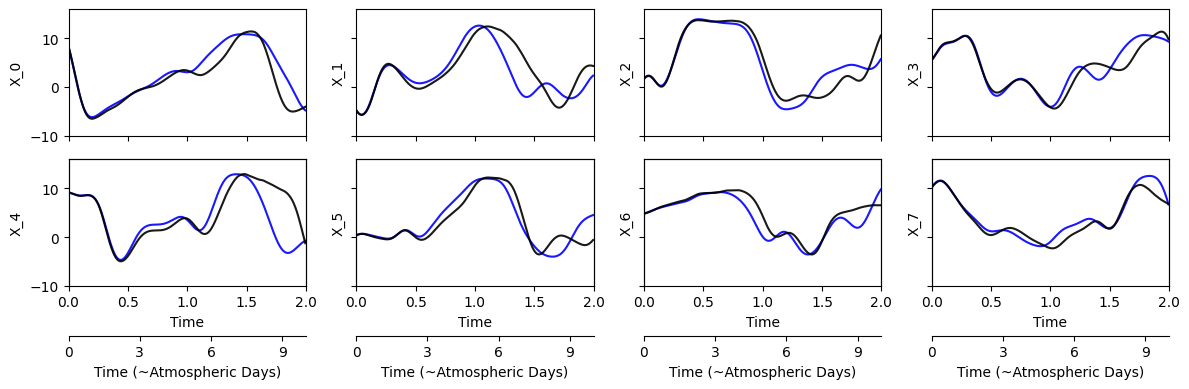

In [15]:
from utils.add_time_axis import add_axis_weather

k = 1
max_steps = 400
plt.clf()
fig, axs = plt.subplots(2, 4, figsize=(12, 4), sharex=True, sharey=True) 
axs = axs.flatten()
# Epistemic
for k in range(K):
    axs[k].plot(time[0:max_steps], X[0:max_steps, k],
    alpha=0.9, color="blue", label="NN")
    axs[k].plot(time[0:max_steps], X_true[0:max_steps, k],
    alpha=0.9, color="black", label="NN")
    axs[k].axis(xmin=0, xmax=int(max_steps*dt_f), ymin = -10., ymax=16.)
    axs[k].set_ylabel(f"X_{k}")
    if k > (K//2)-1:
        axs[k].set_xlabel("Time")
        add_axis_weather(axs[k], 25, 3)
plt.tight_layout()


## Summary
Here, we have shown that we can train a simple neural network to estimate subgrid tendency in the L96 model and run the online simulations. The trajectories show that the simulations start to diverge after around 3 atmospheric days. But we don't have an estimate of the uncertainties in our predictions. Next, we will train a Bayesian neural network to develop stochastic parameterisations that separately quantify epistemic uncertainty (from lack of knowledge in the parameters) and aleatoric uncertainty (from the variability in the training dataset).